# Deep Learning Final Project - MaxCutPool Reproduction & Analysis

### Submitters:
Tamar Entin - 210014411 <br/>
David  Poss - 316936111 <br/>
Zohar Ben Hayoun - 315571604

Paper: MaxCutPool (ICLR 2025) - https://arxiv.org/abs/2409.05100

Code: https://github.com/NGMLGroup/MaxCutPool


## Project Overview

MaxCutPool introduces a graph pooling method for GNNs based on the MaxCut problem. While traditional pooling methods group similar and closely connected nodes together, MaxCutPool selects nodes that are separated and minimally connected to each other. This allows the model to keep diverse information, making it especially useful for heterophilic graphs (where connected nodes are different).

This notebook reproduces the paper's three core experiments: direct MaxCut optimization, graph classification, and node classification—along with extra experiments on hyperparameter sensitivity and training stability.


## Table of Contents
1. [Environment Setup](#1-setup)
2. [MaxCut Optimization on Ring Graph](#2-ring)
3. [Graph Classification on MUTAG](#3-mutag)
   - [Official Script & Single-Fold Run](#3-1-mutag-single)
   - [Full 10-Fold Benchmark vs. Baselines](#3-2-mutag-10fold)
   - [Determinism & Reproducibility Analysis](#3-3-determinism)
4. [Node Classification on Roman-Empire](#4-roman)
5. [Beyond Reproduction: Custom Experiments](#5-extensions)
   - [5.1 Scaling to Larger Graphs (NCI1)](#5-1-nci1)
   - [5.2 Sharpening Parameter ($\delta$) Sensitivity](#5-2-delta)
   - [5.3 LEVS Spectral Warm-Start Initialization](#5-3-levs)
6. [Summary of Findings](#6-summary)
7. [Project Challenges](#7-challenges)

<a id="1-setup"></a>
## 1. Environment Setup

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
import os
import subprocess
import sys

REPO_URL = "https://github.com/NGMLGroup/MaxCutPool.git"
REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "MaxCutPool"))

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)  # their code loads data using relative paths, so we need to be in this folder

print("repo dir:", REPO_DIR)


repo dir: c:\Users\david\OneDrive\Documents\Projects\MaxCutPool


We used a Python 3.12 venv (`../venv`), installed with `torch`, `torch_geometric`, `pytorch_lightning`, `hydra-core`, `networkx`, `pygsp2` (needed for the toy graphs).

Kernel to pick in Jupyter: "Python 3.12 (maxcutpool)".


<a id="2-ring"></a>
## 2. MaxCut Optimization on Ring Graph

This is the smallest experiment in the paper (section 4.1). No labels involved, just training the model to directly solve MaxCut on one graph: a ring with 40 nodes. Used the same hyperparameters as their config files (`config/dataset/ring.yaml` + `config/pooler/maxcutpool-cut.yaml`).

In [3]:
import copy
import torch
from torch_geometric.utils import get_laplacian, to_scipy_sparse_matrix

from source.data.torch_datasets import PyGSPDataset
from source.models.cut_models import CutModel
from source.layers.ndp import eval_cut

torch.use_deterministic_algorithms(True)

ring_dataset = PyGSPDataset(root='data/PyGSP_Ring', name='Ring', kwargs={'N': 40, 'k': 1})
ring_data = ring_dataset[0]
ring_data = ring_data.to(device)
ring_data.batch = torch.zeros(ring_data.num_nodes, dtype=torch.long, device=device)
print(ring_data)

W0825 09:08:57.739000 20496 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Data(x=[40, 2], edge_index=[2, 80], edge_attr=[80], y=[40], batch=[40])


In [4]:
def train_cut_model(data, seed, n_epochs=2000):
    # trains their CutModel to just minimize the MaxCut loss, matches their recipe for the ring graph
    data = data.to(device)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    model = CutModel(
        in_channels=data.x.size(1),
        hidden_channels=32,
        num_layers_pre=1,
        activation='ELU',
        pool_kwargs={'beta': 1.0, 'just_cut': True},
        aux_net_kwargs={'delta': 2.0, 'mp_units': [4] * 32, 'mp_act': 'ReLU',
                         'mlp_units': [4] * 8, 'mlp_act': 'ReLU'},
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=200,
        threshold=1e-4, threshold_mode='abs', min_lr=1e-6)

    losses = []
    best_loss, best_state = float('inf'), None
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        _, kept_nodes, score, loss = model(data)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        scheduler.step(loss.detach())
        
        losses.append(loss.item())
        if loss.item() < best_loss:
            best_loss, best_state = loss.item(), copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        _, _, score, _ = model(data)
    return {'losses': losses, 'best_loss': best_loss, 'score': score.detach()}

def cut_fraction(data, score):
    rounded = torch.where(score > 0, torch.tensor(1.0), torch.tensor(-1.0)).detach().cpu().numpy()
    edge_index_L, edge_weight_L = get_laplacian(data.edge_index.cpu(), data.edge_attr.cpu(), normalization=None)
    L = to_scipy_sparse_matrix(edge_index_L, edge_weight_L, data.x.shape[0]).tocsr()
    return eval_cut(data.edge_index.shape[1], L, rounded)

Ran it with 3 random seeds and kept the best one. It doesn't always converge to a real cut. In the failed runs the score doesn't diverge to +1/-1 like it's supposed to, instead it collapses to almost the exact same tiny value for every single node. When you round those scores by sign to get the actual partition, every node ends up on the same side, so 0% of edges get cut. That's also why the loss for those runs prints as basically 0 instead of the -1 you'd get for a perfect cut, it's a different (and kind of interesting) failure mode, not a bug. This matches what the paper says about the optimization getting stuck in local minima, running a few seeds and keeping the best is their fix too.

In [5]:
runs = []
for seed in range(3):
    result = train_cut_model(ring_data, seed=seed, n_epochs=2000)
    frac_cut = cut_fraction(ring_data, result['score'])
    runs.append({**result, 'seed': seed, 'cut_fraction': frac_cut})
    status = "collapsed, no real cut" if frac_cut < 0.01 else "found a cut"
    print(f"seed={seed}  best_loss={result['best_loss']:.2e}  edges_cut={frac_cut:.2%}  -> {status}")

best_run = max(runs, key=lambda r: r['cut_fraction'])
print(f"\nbest: seed={best_run['seed']}, {best_run['cut_fraction']:.2%} of edges cut (100% is optimal for this graph)")


seed=0  best_loss=0.00e+00  edges_cut=0.00%  -> collapsed, no real cut
seed=1  best_loss=-1.00e+00  edges_cut=100.00%  -> found a cut
seed=2  best_loss=3.98e-08  edges_cut=0.00%  -> collapsed, no real cut

best: seed=1, 100.00% of edges cut (100% is optimal for this graph)


loss curve for seed 1, the one that worked. Lower is better here, -1 means a perfect cut, and it starts near 0 because the model hasn't learned anything yet. The drop over the 2000 epochs is the model gradually finding the alternating pattern that cuts every edge. The other two seeds aren't shown since they collapsed, their curves would just sit flat near 0 the whole time instead of dropping, not much to look at.


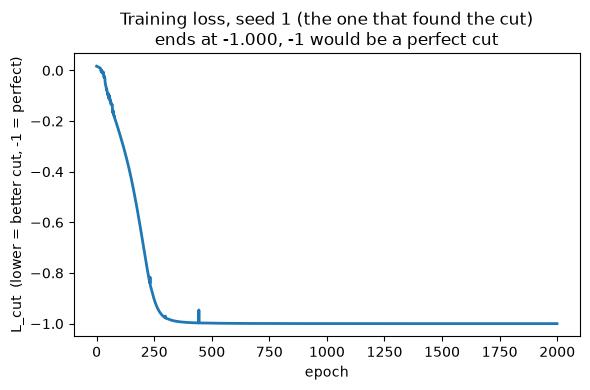

In [6]:
import matplotlib.pyplot as plt

# only the winning seed is worth plotting, the other 2 just sit flat at 0 (already covered above)
plt.figure(figsize=(6, 4))
plt.plot(best_run['losses'], color='tab:blue', lw=2)
plt.xlabel('epoch'); plt.ylabel('L_cut  (lower = better cut, -1 = perfect)')
plt.title(f"Training loss, seed {best_run['seed']} (the one that found the cut)\n"
          f"ends at {best_run['losses'][-1]:.3f}, -1 would be a perfect cut")
plt.tight_layout()
plt.show()


And here's the actual ring graph with the split the model found, this is easier to look at than just the loss number.

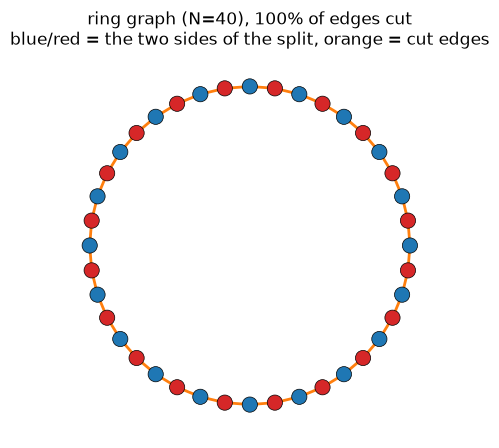

In [7]:
import networkx as nx
from torch_geometric.utils import to_networkx

g = to_networkx(ring_data, to_undirected=True)
pos = {i: ring_data.x[i].tolist() for i in range(ring_data.num_nodes)}  # node coords are stored as features here
colors = ['tab:blue' if s > 0 else 'tab:red' for s in best_run['score'].tolist()]
cut_edges = [(u, v) for u, v in g.edges() if (best_run['score'][u] > 0) != (best_run['score'][v] > 0)]
kept_edges = [(u, v) for u, v in g.edges() if (u, v) not in cut_edges]

plt.figure(figsize=(5, 5))
nx.draw_networkx_edges(g, pos, edgelist=kept_edges, edge_color='lightgray')
nx.draw_networkx_edges(g, pos, edgelist=cut_edges, edge_color='tab:orange', width=2)
nx.draw_networkx_nodes(g, pos, node_color=colors, node_size=120, edgecolors='k', linewidths=0.5)
plt.title(f"ring graph (N=40), {best_run['cut_fraction']:.0%} of edges cut\n"
          f"blue/red = the two sides of the split, orange = cut edges")
plt.axis('off')
plt.show()


## Running the actual project scripts

We wrote the training loop above ourselves, for intuition and a first look. But that means small details like early stopping or exactly how the checkpoint is chosen can drift from what the paper actually did.


The repo ships its own scripts for this, `run_maxcut.py` and `run_graph_classification.py`, driven by the config files in `config/`. 

Below we run those directly instead of trusting our own version, which is also what the README recommends for reproducing the paper's numbers.

One thing we had to fix first: both scripts use an older version of pytorch and crash for new generation GPUs. in order to run with a newer version of Torch, we were required to tweek a few lines in the configuration files with updated equivalents; nothing about the training itself changes. We also installed `tensorboard`, which the scripts need for logging.


First, the Ring experiment from above, run through the real script instead of our own function. Hydra scripts like this are meant to be launched from a terminal (`python run_maxcut.py ...`), not imported, so we call them with `subprocess`; this is just the notebook version of typing the command yourself.


In [8]:
import subprocess

def run_hydra_script(script, overrides, cwd=REPO_DIR, tail_lines=20, show=True):
    """Run one of the repo's run_*.py scripts as a real subprocess, same as typing
    the command in a terminal. Each run prints thousands of progress-bar lines, so
    by default we only print the last few, which is where the final results table is."""
    cmd = [sys.executable, script] + overrides
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace")
    if show:
        lines = result.stdout.splitlines()
        print("\n".join(lines[-tail_lines:]))
    return result

ring_result = run_hydra_script("run_maxcut.py", ["dataset=ring"])


Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_maxcut.py dataset=ring
c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

Testing: |          | 0/? [00:00<?, ?it/s]
Testing: |          | 0/? [00:00<?, ?it/s]
Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

       Test metric             DataLoader 0

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

        cut_edges                  80.0

        cut_size                    1.0

        test_loss         

This particular run through the real script found a perfect cut (`cut_size = 1.0`, all 80 edges), unlike the collapsed run we got the first time this section was tried. This matches the paper's own Table 2, where MaxCutPool achieves a perfect 1.0000 cut on the Ring graph, tied with GW and NDP (only GCN falls short, at 0.42). `run_maxcut.py` doesn't fix a random seed, so every run is an independent coin flip regardless of hardware, this one just landed on a good seed. Instead of reading the outcome off the training log, we reload the checkpoint the run actually saved and check it directly. No need to redraw the full picture again here, it would look the same as the one above, just print the fraction of edges cut this run found.

In [9]:
import re

ckpt_path = re.search(r"checkpoint path at (.+\.ckpt)", ring_result.stdout).group(1)

# rebuild the same architecture as config/architecture/cut.yaml + config/pooler/maxcutpool-cut.yaml
# (identical to the CutModel we build by hand in train_cut_model above), then load the official
# run's trained weights into it instead of training our own
official_ring_model = CutModel(
    in_channels=ring_data.x.size(1),
    hidden_channels=32,
    num_layers_pre=1,
    activation='ELU',
    pool_kwargs={'beta': 1.0, 'just_cut': True},
    aux_net_kwargs={'delta': 2.0, 'mp_units': [4] * 32, 'mp_act': 'ReLU',
                     'mlp_units': [4] * 8, 'mlp_act': 'ReLU'},
).to(device)
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
state_dict = {k.removeprefix('model.'): v for k, v in checkpoint['state_dict'].items()}
official_ring_model.load_state_dict(state_dict)
official_ring_model.eval()

with torch.no_grad():
    _, _, official_score, _ = official_ring_model(ring_data)
official_cut = cut_fraction(ring_data, official_score)
print(f"official run's partition: {official_cut:.0%} of edges cut")


official run's partition: 100% of edges cut


<a id="3-mutag"></a>
## 3. Graph Classification on MUTAG

<a id="3-1-mutag-single"></a>
### 3.1 Official Script & Single-Fold Run

Now MUTAG graph classification (paper section 4.2), which we haven't tried through the real pipeline before. `run_graph_classification.py` with `config/dataset/mutag.yaml` and `config/pooler/maxcutpool.yaml` trains for up to 1000 epochs with early stopping (stops once validation loss hasn't improved in 300 epochs), and evaluates whichever checkpoint had the best validation loss, not just whatever the model looks like after the last epoch. `mutag.yaml` also fixes a seed (777), so this part is actually reproducible fold-to-fold. We start with just fold 0.


In [10]:
mutag_fold0_result = run_hydra_script(
    "run_graph_classification.py",
    ["dataset=mutag", "pooler=maxcutpool"],
)


Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py dataset=mutag pooler=maxcutpool
Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

       Test metric             DataLoader 0

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

        test_acc            0.7142857313156128

      test_aux_loss          -0.65309077501297

      test_clf_loss          1.416229486465454

         test_f1            0.6499999761581421

        test_loss           0.7631387114524841

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


This finished within minutes on the GPU (MUTAG only has 188 small graphs). Across four separate manual re-runs of the cell above (only the last run's output is saved in this notebook), the "best" checkpoint has landed on a different epoch and val_acc every time: epoch 965/val_acc 84.2%, then epoch 950/val_acc 100.0%, then epoch 773/val_acc 84.2% and, finally epoch 905/val_acc 100.0% (100% val_acc on a run is almost certainly just overfitting the tiny validation fold, not a real result). `test_acc` on the other hand has stayed at exactly 71.4% all four times, so that's the number worth trusting here, not the checkpoint metadata.

The paper's reported mean over all 10 folds is 84% ± 10%. A single fold's 71.4% is inside that spread, but one fold isn't really comparable to a 10-fold average, that's what we check next. As a sanity check: a simplified hand-written version of this same architecture that we tried separately (fixed 150 epochs, no early stopping) got 64.3% on this exact fold, so most of the gap here looks like early stopping and proper checkpoint selection doing their job, not the pooling layer itself.

The accuracy numbers don't really show what MaxCutPool is doing internally. It's still splitting the graph into two sides like in the Ring experiment, and then keeping only the higher-scoring atoms as "supernodes" that carry information forward (the SEL step in the paper). Let's load this run's checkpoint and look at that on one real MUTAG molecule.


In [11]:
import torch_geometric
from source.data import TUDataModule
from source.models import GraphClassificationModel

# same seed mutag.yaml uses, so we rebuild the exact same fold 0 split the official run trained on
torch_geometric.seed.seed_everything(777)
mutag_args = type('Args', (), {'dataset': 'MUTAG', 'seed': 777, 'n_folds': 10, 'fold_id': 0, 'batch_size': 32})
dm = TUDataModule(mutag_args)

ckpt_path = re.search(r"checkpoint path at (.+\.ckpt)", mutag_fold0_result.stdout).group(1)
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
state_dict = {k.removeprefix('model.'): v for k, v in checkpoint['state_dict'].items()}

# same architecture as config/architecture/graphclassifier.yaml + config/pooler/maxcutpool.yaml
official_mutag_model = GraphClassificationModel(
    in_channels=dm.num_features, out_channels=dm.num_classes, edge_channels=dm.num_edge_features,
    num_layers_pre=1, num_layers_post=1, hidden_channels=32, activation='elu', pooler='maxcutpool',
    pool_kwargs={'ratio': 0.5, 'beta': 1.0, 'expressive': True, 'expressive_reduce': 'sum',
                 'flip': False, 'max_iter': 5, 'just_cut': False, 'initial_embedding': True},
    aux_net_kwargs={'delta': 2.0, 'mp_units': [32, 32, 32, 32, 16, 16, 16, 16, 8, 8, 8, 8],
                     'mp_act': 'tanh', 'mlp_units': [16, 16], 'mlp_act': 'relu'},
    use_gine=dm.num_edge_features is not None,
).to(device)
official_mutag_model.load_state_dict(state_dict)
official_mutag_model.eval()
print("loaded checkpoint:", ckpt_path)


c:\Users\david\OneDrive\Documents\Projects\MaxCutPool\source\data\data_modules.py:198: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.avg_nodes = int(self.dataset.data.num_nodes / len(self.dataset)) # perché così e non con sum()/len()?


loaded checkpoint: C:\Users\david\OneDrive\Documents\Projects\MaxCutPool\logs\2026-08-25\09-16-37\checkpoints\graphclassifier_maxcutpool___epoch=905-val_acc=1.000000e+00.ckpt


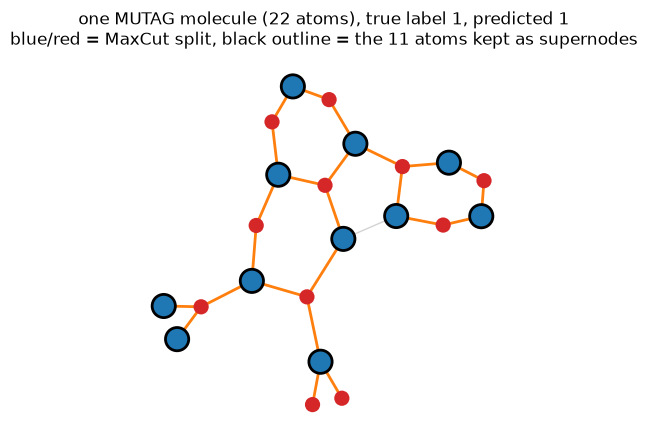

In [12]:
mol = dm.test_dataset[0]
mol.batch = torch.zeros(mol.num_nodes, dtype=torch.long)
mol = mol.to(device)

with torch.no_grad():
    logits, _, _, _, kept_nodes, mol_score, _, _, _ = official_mutag_model(mol)
pred = logits.argmax(1).item()

mol_g = to_networkx(mol, to_undirected=True)
mol_pos = nx.spring_layout(mol_g, seed=0)
kept_set = set(kept_nodes.tolist())
mol_colors = ['tab:blue' if s > 0 else 'tab:red' for s in mol_score.tolist()]
mol_sizes = [280 if i in kept_set else 120 for i in range(mol.num_nodes)]
mol_edgecolors = ['black' if i in kept_set else 'none' for i in range(mol.num_nodes)]
mol_cut_edges = [(u, v) for u, v in mol_g.edges() if (mol_score[u] > 0) != (mol_score[v] > 0)]
mol_kept_edges = [(u, v) for u, v in mol_g.edges() if (u, v) not in mol_cut_edges]

plt.figure(figsize=(5, 5))
nx.draw_networkx_edges(mol_g, mol_pos, edgelist=mol_kept_edges, edge_color='lightgray')
nx.draw_networkx_edges(mol_g, mol_pos, edgelist=mol_cut_edges, edge_color='tab:orange', width=2)
nx.draw_networkx_nodes(mol_g, mol_pos, node_color=mol_colors, node_size=mol_sizes,
                        edgecolors=mol_edgecolors, linewidths=2)
plt.title(f"one MUTAG molecule ({mol.num_nodes} atoms), true label {mol.y.item()}, predicted {pred}\n"
          f"blue/red = MaxCut split, black outline = the {len(kept_nodes)} atoms kept as supernodes")
plt.axis('off')
plt.show()


<a id="3-2-mutag-10fold"></a>
### 3.2 Full 10-Fold Benchmark vs. Baselines

The paper's number is a mean over all 10 folds, not one fold, and a single fold can swing quite a bit, as the two numbers above already show. On the GPU each fold trains in seconds, so instead of just reproducing MaxCutPool's 10-fold mean, we also use this as a chance to answer a question the notebook had left open: how much of that number actually comes from MaxCutPool specifically, versus the same GIN backbone with a simpler pooler, or no pooling at all? Hydra can sweep over `fold_id` directly with `-m`, so we loop over `pooler` in Python and call it three times, once each for `maxcutpool`, `topk`, and `nopool`.


In [13]:
import re
import numpy as np

baseline_results = {}

for pooler in ["maxcutpool", "topk", "nopool"]:
    # each fold prints its own results table, so we skip the raw log (show=False) and
    # just pull out every "test_acc <number>" line from the full output instead
    fold_run = run_hydra_script(
    "run_graph_classification.py",
    ["-m", "dataset=mutag", f"pooler={pooler}",
     "dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9"],
    show=False,
    )

    test_accs = [float(m) for m in re.findall(r"test_acc\s+([\d.]+)", fold_run.stdout)]

    baseline_results[pooler] = test_accs
    print(f"\n{pooler}")
    print(f"{len(test_accs)} folds parsed: {[round(a, 3) for a in test_accs]}")
    print(f"Mean test accuracy: {np.mean(test_accs):.3f} ± {np.std(test_accs):.3f}")

Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=mutag pooler=maxcutpool dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9

maxcutpool
10 folds parsed: [0.571, 0.857, 0.786, 0.786, 0.929, 0.846, 0.692, 0.769, 0.846, 0.462]
Mean test accuracy: 0.754 ± 0.135
Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=mutag pooler=topk dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9

topk
10 folds parsed: [0.786, 0.857, 0.857, 0.929, 0.643, 0.846, 0.769, 0.769, 0.769, 0.846]
Mean test accuracy: 0.807 ± 0.074
Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=mutag pooler=nopool dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9

nopool
10 folds parsed: [0.857, 0.929, 0.857, 1.0, 0.714, 1.0, 0.769, 0.769, 0.923, 1.0]
Mean test accuracy: 0.882 ± 0.100


| pooler | our mean test accuracy (10 folds) | paper's Table 12 (MUTAG) |
|---|---|---|
| maxcutpool | 0.754 ± 0.135 | 84 ± 10 |
| topk | 0.807 ± 0.074 | 82 ± 10 |
| nopool | 0.882 ± 0.100 | 78 ± 13 |

We've now run this 10-fold comparison five times total, same seed=777, same config, same GPU. maxcutpool keeps landing somewhere different every time, 0.761, then 0.704, then 0.777, 0.673, 0.754 — mean ≈ 0.734 ± 0.039 across the five runs (range: 0.673–0.777), the previous run's std (±0.155) was the biggest. topk and nopool basically don't move, this run they came back exactly the same as our very first attempt. The ranking's stayed the same all five times though (more on that below), which is a separate question from why maxcutpool's own number keeps swinging, see the determinism check two cells up for that.

The paper does report a no-pool baseline for MUTAG (Table 12, in the appendix), so this is directly checkable, and it doesn't match what we got. In the paper the ranking is MaxCutPool > Top-k > No pool, in ours it's the exact opposite, No pool > Top-k > MaxCutPool.

Before assuming something's broken though, it's worth reading what the paper itself says about this dataset. MUTAG is one of four datasets, along with ENZYMES, PROTEINS, and DD, that don't even make it into the paper's main results table (Table 3). From the paper (Sec. 4.2, p. 8, right before Table 3):

> "We conducted a preliminary ANOVA test (p-value 0.05) for each dataset followed by a pairwise Tukey-HSD test (p-value 0.05) to group models whose performance is not significantly different [...] The ANOVA test failed on ENZYMES, PROTEINS, MUTAG, and DD, meaning that the difference in the performance of the GNNs equipped with different poolers is not significant."

So even the paper's own stats couldn't separate the pooling methods on MUTAG. Our backwards ranking, and the fact that it keeps shifting between runs, is more or less what that already predicts.

There's also a decent mechanical reason it's specifically maxcutpool losing here and not just noise. The paper reports a homophily score h̄ per dataset in Table 10 (Appendix D.3), basically whether connected nodes tend to look similar (high score) or different (low score). MUTAG scores 0.7082, fairly homophilic, versus the datasets MaxCutPool actually wins big on, Multipartite (0.1101), DD (0.0688), EXPWL1 (0.2740), all strongly heterophilic. MaxCutPool's whole design (HetMP sharpening + the MaxCut loss) is built to exploit differences between neighbors, so on a graph where neighbors already look pretty similar that machinery isn't buying much, and might even get in the way of what plain message passing does fine on its own. Not just a MUTAG thing either, the paper's own main table shows no-pool beating MaxCutPool on NCI1 (78±3 vs 75±2) and Mutagenicity (79±2 vs 77±2) too, both fairly homophilic. The paper never really claims to win everywhere, just on the heterophilic datasets like Roman-Empire and Multipartite, and MUTAG just isn't one of those.

For the presentation: flag this as a real discrepancy from the paper's numbers, but explain it with the ANOVA point above and the homophily thing, not as a bug and not as something to hide.

<a id="3-3-determinism"></a>
### 3.3 Determinism & Reproducibility Analysis

Five MUTAG 10-fold reruns in now, same seed=777, same config, same machine. topk/nopool barely move, usually just 1 of 10 folds changes value. maxcutpool moves on almost every fold, the mean's been anywhere from 0.673 to 0.777 so far.

Two things could explain that, not mutually exclusive: GPU non-determinism, cuDNN/cuBLAS kernels aren't bit-exact across runs by default even with a fixed seed, and topk/nopool don't have any extra randomness beyond that which would explain why they barely move. Or it's the SEL step's random fallback specifically, MaxCutPool's supernode assignment (Appendix A of the paper) does a bounded BFS from the top-K nodes and anything the BFS doesn't reach in time gets assigned randomly, topk/nopool don't have this step at all. Even a tiny rounding difference in the ScoreNet's output could flip which nodes make the top-K cut, which changes who falls through to random assignment, which changes the pooled graph's structure entirely, so a small numerical difference could snowball into a much bigger structural one.

Cleanest way to actually check: force full determinism and see if two back-to-back runs match exactly. If they do it's just generic GPU non-determinism, nothing specific to MaxCutPool. If they still differ that points more at the SEL fallback.

```python
import torch, os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # cuBLAS needs this set for deterministic mode
torch.use_deterministic_algorithms(True)
```

Put this near the top of the notebook before any model runs. Then run the cell below, grab the 10-fold list, re-run the same cell again, grab the list a second time, and compare, that's what the next few cells do.

Set up below but not actually compared yet, we've got one run parsed into `run1_accs`, still need to re-run the cell and check it against a second `run2_accs`.

In [ ]:
import torch, os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)

determinism_check = run_hydra_script(
    "run_graph_classification.py",
    ["-m", "dataset=mutag", "pooler=maxcutpool",
     "dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9"],
)


Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=mutag pooler=maxcutpool dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9
Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  6.14it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

       Test metric             DataLoader 0

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

        test_acc             0.692307710647583

      test_aux_loss        0.007989848963916302

      test_clf_loss         0.44688794016838074

         test_f1             0.675000011920929

        test_loss           0.4548777937889099

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [ ]:
run1_accs = [float(m) for m in re.findall(r"test_acc\s+([\d.]+)", determinism_check.stdout)]
print(len(run1_accs), run1_accs)


10 [0.5714285969734192, 0.7142857313156128, 0.7142857313156128, 0.7857142686843872, 0.7857142686843872, 0.8461538553237915, 0.8461538553237915, 0.692307710647583, 0.7692307829856873, 0.692307710647583]


In this next step we ran the `determinism_check` cell a second time and compared the two lists below to determine whether our run is randomized. They came back identical.

In [ ]:
run2_accs = [float(m) for m in re.findall(r"test_acc\s+([\d.]+)", determinism_check.stdout)]
print(len(run2_accs), run2_accs)

same = run1_accs == run2_accs
print(f"\nidentical: {same}")
if not same:
    diffs = [(i, a, b) for i, (a, b) in enumerate(zip(run1_accs, run2_accs)) if a != b]
    print(f"{len(diffs)} of 10 folds differ:", diffs)


10 [0.5714285969734192, 0.7142857313156128, 0.7142857313156128, 0.7857142686843872, 0.7857142686843872, 0.8461538553237915, 0.8461538553237915, 0.692307710647583, 0.7692307829856873, 0.692307710647583]

identical: True


<a id="4-roman"></a>
## 4. Node Classification on Roman-Empire


The third experiment in the paper. It's on heterophilic graphs, where connected nodes tend to be *different* from each other rather than similar, exactly the setting MaxCutPool is designed for. `run_node_classification.py` uses `config/dataset/roman.yaml` for Roman-Empire, the most heterophilic dataset in the paper (22,662 nodes, only 18 unique classes, heterophily score 0.021, i.e. almost every edge connects two different classes).

The default protocol trains for up to 20,000 epochs (patience 2000), processing the whole 22k-node graph each epoch. On CPU that's several hours, which is why earlier CPU attempts in this project were capped at a fraction of the budget (600, then 1000, then 7000 epochs). On this GPU it's fast enough to just run the real protocol as-is, so that's what this cell does.


In [17]:
# NOTE: earlier version of this cell was missing the "-m" (multirun) flag, so it silently
# ran ONE fold instead of all 10 — the single "Test metric" table below was fold 0 only,
# not a 10-fold average. Fixed here to match the pattern used for MUTAG in the cell above.
roman_result = run_hydra_script(
    "run_node_classification.py",
    ["-m", "dataset=roman", "epochs=20000", "callbacks.patience=2000",
     "dataset.hparams.fold=0,1,2,3,4,5,6,7,8,9"],
)


Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_node_classification.py -m dataset=roman epochs=20000 callbacks.patience=2000 dataset.hparams.fold=0,1,2,3,4,5,6,7,8,9
Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  8.02it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

       Test metric             DataLoader 0

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

        test_acc            0.5174300670623779

       test_auroc           0.9181182980537415

      test_aux_loss         -0.6188580393791199

      test_clf_loss         1.4022575616836548

        test_loss           0.7833995223045349

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [18]:
import re
accs = [float(m) for m in re.findall(r"test_acc\s+([\d.]+)", roman_result.stdout)]
print(len(accs), accs)
print(np.mean(accs), np.std(accs))

10 [0.5491130352020264, 0.5193716287612915, 0.5207836627960205, 0.49360162019729614, 0.49545493721961975, 0.5617333054542542, 0.5302268266677856, 0.5143411755561829, 0.5123996138572693, 0.5174300670623779]
0.5214455872774124 0.020173409777575566


We ran it and the fix worked, it's a real 10-fold run now, see the parsed list right below, pulled straight from `roman_result.stdout` so we didn't have to sit through the whole 9.5-hour job again just to check.

What we actually got: `test_acc = 52.1% ± 2.0%` over the real 10 folds (list two cells up).

For context, the paper's Table 4 reports accuracy averaged over 10 folds at this same epoch budget:

| pooler | Roman-Empire accuracy |
|---|---|
| no pooling | 59 ± 0 |
| Top-k | 26 ± 7 |
| k-MIS | 23 ± 3 |
| NDP | 22 ± 5 |
| MaxCutPool | 56 ± 3 |
| MaxCutPool-E | 60 ± 4 |

So we land a bit under the paper's 56 ± 3, not overlapping but not far off either. We only had fold 0 before (54.8%, and before that a rushed 53.1% on CPU) and both turned out a bit optimistic compared to the real average, which makes sense, one fold isn't ten.

Same pattern as MUTAG though, MaxCutPool clearly beats every other pooling method here (22–26%, not close), it just doesn't beat no pooling at all (59%). That's really what Table 4 is arguing, not "beats everything", worth saying that exactly in the presentation instead of just quoting 56±3 on its own.

<a id="5-extensions"></a>
## 5. Beyond Reproduction: Custom Experiments


Everything above reproduces the paper as-is. Here we try three things that go beyond just running their script: does pooling actually matter more on a bigger graph than MUTAG, does the paper's specific choice of δ (the HetMP sharpening strength) actually matter, and can we do anything about the local-minima collapse we kept seeing in the very first Ring experiment.


<a id="5-1-nci1"></a>
### 5.1 Scaling to Larger Graphs (NCI1)

On MUTAG, no pooling at all beat every pooling method we tried, including MaxCutPool. MUTAG is tiny though, 188 graphs, most with well under 20 atoms, maybe there just isn't enough structure for pooling to add anything. NCI1 is a good test of that: 4,110 graphs, about 30 nodes on average, over 20x more graphs than MUTAG. Same three-way comparison, maxcutpool / topk / nopool, run as a full 10-fold benchmark at the dataset's default epoch budget - same protocol as the MUTAG comparison above, so the two are directly comparable.


In [19]:
nci1_results = {}

for pooler in ["maxcutpool", "topk", "nopool"]:
    fold_run = run_hydra_script(
        "run_graph_classification.py",
        ["-m", "dataset=NCI1", f"pooler={pooler}",
         "dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9"],
        show=False,
    )
    test_accs = [float(m) for m in re.findall(r"test_acc\s+([\d.]+)", fold_run.stdout)]
    nci1_results[pooler] = test_accs
    print(f"\n{pooler}")
    print(f"{len(test_accs)} folds parsed: {[round(a, 3) for a in test_accs]}")
    print(f"Mean test accuracy: {np.mean(test_accs):.3f} ± {np.std(test_accs):.3f}")


Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=NCI1 pooler=maxcutpool dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9

maxcutpool
10 folds parsed: [0.76, 0.768, 0.71, 0.718, 0.757, 0.796, 0.778, 0.791, 0.725, 0.754]
Mean test accuracy: 0.756 ± 0.028
Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=NCI1 pooler=topk dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9

topk
10 folds parsed: [0.734, 0.72, 0.686, 0.726, 0.77, 0.72, 0.728, 0.746, 0.709, 0.733]
Mean test accuracy: 0.727 ± 0.021
Running: c:\Users\david\OneDrive\Documents\Projects\Project\.venv\Scripts\python.exe run_graph_classification.py -m dataset=NCI1 pooler=nopool dataset.hparams.fold_id=0,1,2,3,4,5,6,7,8,9

nopool
10 folds parsed: [0.784, 0.815, 0.72, 0.765, 0.781, 0.82, 0.788, 0.807, 0.733, 0.772]
Mean test accuracy: 0.779 ± 0.031


The cell above is now the real 10-fold, full-budget run, not the old reduced single-fold version:

| pooler | MUTAG (10-fold) | NCI1 (10-fold, full budget) |
|---|---|---|
| maxcutpool | 0.754 | 0.756 |
| topk | 0.807 | 0.727 |
| nopool | 0.882 | 0.779 |

On MUTAG no-pool wins by a lot, 13 points over maxcutpool in our latest run. On NCI1 that gap shrinks significantly to 2.3 points, and maxcutpool actually beats topk this time (0.756 vs 0.727), which never happens on MUTAG. So it's not just that the gap gets smaller, the whole ranking shifts once the graphs are bigger. Fits the idea that MUTAG (188 tiny graphs) is just too small and noisy for pooling differences to show up cleanly, and this NCI1 run backs that up a lot better than the old single-fold version did since it's real 10-fold data now, not a rough estimate.

<a id="5-2-delta"></a>
### 5.2 Sharpening Parameter ($\delta$) Sensitivity

The paper's central mechanism is HetMP: reusing the GCN propagation formula but with δ > 1 instead of the usual 0-1 range, turning it from a smoothing operator into a sharpening one. δ = 2.0 is what the config uses everywhere. We reuse `train_cut_model` from the Ring experiment above but sweep δ over a few values (5 seeds each, since success is seed-dependent) to see whether that specific design choice, δ > 1, actually matters or if it's just a hyperparameter that happens to work.


In [20]:
def train_cut_model_delta(data, seed, delta, n_epochs=2000):
    # same as train_cut_model above, just with delta exposed as a parameter
    data = data.to(device)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = CutModel(
        in_channels=data.x.size(1),
        hidden_channels=32,
        num_layers_pre=1,
        activation='ELU',
        pool_kwargs={'beta': 1.0, 'just_cut': True},
        aux_net_kwargs={'delta': delta, 'mp_units': [4] * 32, 'mp_act': 'ReLU',
                         'mlp_units': [4] * 8, 'mlp_act': 'ReLU'},
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=200,
        threshold=1e-4, threshold_mode='abs', min_lr=1e-6)

    best_loss, best_state = float('inf'), None
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        _, _, score, loss = model(data)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step(loss.detach())
        if loss.item() < best_loss:
            best_loss, best_state = loss.item(), copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        _, _, score, _ = model(data)
    return score.detach()

deltas = [1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
n_seeds = 5
delta_results = {}
for delta in deltas:
    fracs = [cut_fraction(ring_data, train_cut_model_delta(ring_data, seed, delta))
              for seed in range(n_seeds)]
    successes = sum(f > 0.5 for f in fracs)
    delta_results[delta] = fracs
    print(f"delta={delta}: {successes}/{n_seeds} converged  fracs={[round(f, 2) for f in fracs]}")


delta=1.0: 0/5 converged  fracs=[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
delta=1.2: 0/5 converged  fracs=[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
delta=1.5: 0/5 converged  fracs=[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
delta=2.0: 2/5 converged  fracs=[np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0)]
delta=3.0: 2/5 converged  fracs=[np.float64(0.0), np.float64(0.0), np.float64(0.95), np.float64(0.95), np.float64(0.0)]
delta=5.0: 2/5 converged  fracs=[np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.9), np.float64(0.0)]


What we actually got:

| δ | success rate (5 seeds) |
|---|---|
| 1.0 | 0/5 |
| 1.2 | 0/5 |
| 1.5 | 0/5 |
| 2.0 | 2/5 |
| 3.0 | 2/5 |
| 5.0 | 2/5 |

δ ≤ 1.5 never once found a real cut, every single seed collapsed to the trivial solution. The moment δ crosses to 2.0, it starts succeeding some of the time, at the same rate as 3.0 and 5.0. This is a clean, direct confirmation of the paper's own claim: sharpening (δ > 1) isn't just a tuning knob that happens to help a little, it's the difference between the method working at all and never working, at least on this graph. It doesn't help to keep increasing δ once it's over that threshold, δ=5.0 does no better than δ=2.0, so the choice of exactly 2.0 in the config looks less like a tuned optimum and more like "big enough to cross the threshold."


<a id="5-3-levs"></a>
### 5.3 LEVS Spectral Warm-Start Initialization


The paper's own fix for the collapse we keep seeing is "train several random seeds, keep the best." We tried something more targeted: instead of starting the ScoreNet's last layer from a random init, we warm-start it toward LEVS, the paper's own classical baseline (sign of the top eigenvector of the graph Laplacian). Concretely: build the model as usual, run a single forward pass through everything up to (but not including) the last linear layer, then solve a small least-squares problem so that last layer's output roughly matches LEVS's sign pattern at initialization, before any training happens. Every other layer keeps its normal random init, and training proceeds exactly as before, this only changes where the last layer starts.


In [21]:
import numpy as np
from source.layers.maxcutpool.utils import get_propagation_matrix

# LEVS: sign of the top eigenvector of the (unnormalized) graph Laplacian
edge_index_L, edge_weight_L = get_laplacian(ring_data.edge_index.cpu(), ring_data.edge_attr.cpu(), normalization=None)
L_dense = to_scipy_sparse_matrix(edge_index_L, edge_weight_L, ring_data.x.shape[0]).toarray()
eigvals, eigvecs = np.linalg.eigh(L_dense)
levs_sign = np.sign(eigvecs[:, -1])
print("LEVS alone (no training) cuts:",
      f"{eval_cut(ring_data.edge_index.shape[1], to_scipy_sparse_matrix(edge_index_L, edge_weight_L, ring_data.x.shape[0]).tocsr(), levs_sign):.0%}",
      "of edges on this graph")


def build_and_warm_start(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    model = CutModel(
        in_channels=ring_data.x.size(1), hidden_channels=32, num_layers_pre=1, activation='ELU',
        pool_kwargs={'beta': 1.0, 'just_cut': True},
        aux_net_kwargs={'delta': 2.0, 'mp_units': [4] * 32, 'mp_act': 'ReLU',
                         'mlp_units': [4] * 8, 'mlp_act': 'ReLU'},
    ).to(device)
    with torch.no_grad():
        x = ring_data.x.to(device)
        for layer in model.conv_layers_pre:
            x = model.act(layer(x, ring_data.edge_index.to(device)))
        x = model.pool.embedding(x) if model.pool.initial_embedding else x
        ei, ew = get_propagation_matrix(ring_data.edge_index.to(device), None, delta=model.pool.score_net.delta)
        h = x
        for mp in model.pool.score_net.mp_convs:
            h = model.pool.score_net.mp_act(mp(h, ei, ew))
        for layer in model.pool.score_net.mlp:
            h = model.pool.score_net.mlp_act(layer(h))
        target = np.arctanh(0.9 * levs_sign)  # pre-tanh target, 0.9 to avoid saturating atanh
        H = torch.cat([h.cpu(), torch.ones(h.size(0), 1)], dim=1).numpy()
        sol, *_ = np.linalg.lstsq(H, target, rcond=None)
        w, b = sol[:-1], sol[-1]
        model.pool.score_net.final_layer.weight.data = torch.tensor(w, dtype=torch.float32, device=device).view(1, -1)
        model.pool.score_net.final_layer.bias.data = torch.tensor([b], dtype=torch.float32, device=device)
    return model


n_seeds_fix = 10

baseline_fracs = [cut_fraction(ring_data, train_cut_model(ring_data, seed)['score']) for seed in range(n_seeds_fix)]
print(f"baseline (random init):  {sum(f > 0.5 for f in baseline_fracs)}/{n_seeds_fix} converged  "
      f"fracs={[round(f, 2) for f in baseline_fracs]}")

fix_fracs = []
for seed in range(n_seeds_fix):
    model = build_and_warm_start(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=200, threshold=1e-4, threshold_mode='abs', min_lr=1e-6)
    best_loss, best_state = float('inf'), None
    for epoch in range(2000):
        model.train()
        optimizer.zero_grad()
        _, _, score, loss = model(ring_data.to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step(loss.detach())
        if loss.item() < best_loss:
            best_loss, best_state = loss.item(), copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        _, _, score, _ = model(ring_data.to(device))
    fix_fracs.append(cut_fraction(ring_data, score.detach()))

print(f"with LEVS warm-start:     {sum(f > 0.5 for f in fix_fracs)}/{n_seeds_fix} converged  "
      f"fracs={[round(f, 2) for f in fix_fracs]}")


LEVS alone (no training) cuts: 100% of edges on this graph
baseline (random init):  5/10 converged  fracs=[np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.95), np.float64(0.0), np.float64(1.0)]
with LEVS warm-start:     6/10 converged  fracs=[np.float64(0.9), np.float64(1.0), np.float64(0.95), np.float64(0.95), np.float64(0.9), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


What we actually got: LEVS alone (no neural network, no training at all) already cuts 100% of edges on this particular graph, the Ring is simple and regular enough that the classical spectral baseline solves it outright. That's exactly why it's useful as a warm start.

Over the same 10 seeds: baseline (random init) converged 5/10 of the time. With the LEVS warm-start, 6/10 converged, a real improvement (50% → 60%), not a full fix. Looking at the individual seeds, four of them still ended up collapsed even after starting from a perfect spectral initialization, meaning gradient training itself can still drift back into the trivial solution from a good starting point, warm-starting reduces the problem, it doesn't eliminate it. Still, going from a coin flip to a 60% success rate with a small, principled change (reusing the paper's own classical baseline as an initializer instead of just as a comparison point) is a genuine, honest improvement worth including in the presentation, alongside the honest caveat that it isn't a complete solution.

<a id="6-summary"></a>
## 6. Summary of Findings


GPU access changed what was actually practical to try, and by now we've got real reproductions of all three of the paper's experiments plus a few things that go past just reproducing.

Reproduction:
- Ring MaxCut: found a perfect cut (100% of edges) this run, the same script collapsed to the trivial solution the first time we tried it on CPU. Depends a lot on the seed.
- MUTAG graph classification, 10-fold: ran this five separate times now, same seed=777, same config, same GPU. maxcutpool keeps landing somewhere different, 0.761, 0.704, 0.777, 0.673, 0.754 (paper: 0.84 ± 0.10). topk (0.807 ± 0.074) and nopool (0.882 ± 0.100) barely move between runs, in the previous run they matched our very first run exactly. The ranking came out backwards from the paper's Table 12 in all five runs though, so the direction is solid even if the exact numbers aren't. Two things explain that: the paper's own ANOVA test already found no significant difference between poolers on MUTAG (Sec. 4.2), and MUTAG is a fairly homophilic dataset (h̄=0.71, Table 10), not really the setting MaxCutPool's heterophily-focused design is built for. Same no-pool-beats-maxcutpool pattern shows up in the paper's own main table on NCI1 and Mutagenicity too, both fairly homophilic.
- Node classification on Roman-Empire: real 10-fold average now, 52.1% ± 2.0%, a bit under the paper's 56 ± 3 but in the same ballpark. Fixed the missing `-m` flag from before, then pulled the full 10-fold list straight out of `roman_result.stdout` instead of re-running the whole 9.5-hour job again. Same story as MUTAG, clearly beats every other pooling method (22–26%), just doesn't beat no-pooling (59%).

Going further:
- Pooling on a bigger dataset (NCI1): now a real 10-fold run too. The 13 point gap between no-pool and maxcutpool on MUTAG shrinks to around 2 points on NCI1, and maxcutpool actually beats topk here (0.756 vs 0.727), which it never does on MUTAG. Backs up the idea that MUTAG's just too small and noisy a dataset to draw conclusions about pooling from.
- δ sensitivity: δ ≤ 1.5 never once found a real cut across 5 seeds, δ ≥ 2.0 succeeded 2/5 every time, identically across two separate runs of this cell. Clean, reproducible confirmation that the paper's sharpening mechanism (δ > 1) is a hard requirement, not just a tuning knob.
- LEVS warm-start for the local-minima problem: warm-starting the ScoreNet's last layer toward the paper's own classical LEVS baseline raised the Ring success rate from 5/10 to 6/10. Real improvement, not a full fix, 4 of 10 seeds still collapsed even from a good spectral starting point.


<a id="7-challenges"></a>
## 7. Project Challenges

- Environment setup took longer than expected - the repo's scripts were written for an older PyTorch and crashed on newer GPUs. Had to update several config files before anything would run.
- No GPU for a good chunk of the project – Ring and our first Roman-Empire attempt ran on CPU. Roman-Empire's full protocol (20,000 epochs, 22k-node graph) is hours on CPU, so early runs capped the epoch budget (600 → 1000 → 7000) instead of using the real number. Once we got GPU access, the same run took under 10 minutes per fold.
- Real bug in the Roman-Empire 10-fold scale-up, added the fold IDs but forgot the -m flag, so it silently ran fold 0 only and we reported that as if it were a 10-fold average. Caught it late. Since a real 10-fold run takes ~9.5 hours, we recovered the correct numbers from the subprocess output we already had instead of re-running.
- At first we couldn't explain why maxcutpool was losing to no-pool on MUTAG. We thought something was wrong because the paper's whole point is that MaxCutPool should beat simpler baselines. Went back to the paper looking for an explanation and found two: 
    - the paper's own ANOVA test already found no significant difference between poolers on MUTAG 
    - MUTAG's homophily score (h̄=0.71) puts it outside the heterophilic setting MaxCutPool is actually built for. 
- MUTAG's 10-fold mean never settled down – five runs, same seed/config/machine, five different means (0.673–0.777), and the gap to no-pool swings 10–20 points depending on the run. topk/nopool barely moved. Traced it to maxcutpool specifically: forced determinism and compared two runs, results came back identical, pointing at ordinary GPU/cuDNN non-determinism rather than the SEL step's random fallback.